In [7]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

from mtj.init import init_m
from mtj.llg_heun import LLG_Heun
from mtj.calc_energy import measure_precession
from mtj.constants import VACUUM_PERMEABILITY, hbar, e

In [8]:
Ms = 1 / VACUUM_PERMEABILITY
m0 = np.array([0.9, 0.001, 0.001])

The spin polarization factor is defined as
$$
\eta = \frac{\sqrt{TMR(TMR+2)}}{2(TMR+1)}.
$$
If we assume we have $TMR=1$, the spin polarisation factor $\eta = \frac{\sqrt{3}}{4}.$ 

We assume $a_\perp=0$ and 
$$
a_\parallel = \frac{\hbar}{-2 e} \cdot \frac{\eta}{\mu_0 M_s t} \cdot \frac{V}{R_{PP}S}=\frac{\hbar}{-2 e} \cdot \frac{\eta}{\mu_0 M_s} \cdot \frac{1}{R_{PP}},
$$
with $t$ being the free layer thickness, $S$ the cross-sectional area of the free layer and $V=t\cdot S$ the volume of the free layer. $R_{PP}$ is the resistance of the MTJ in the parallel state.

In [9]:
a_para = hbar / (2 * e) * np.sqrt(3) / (4 * VACUUM_PERMEABILITY * Ms * 1e3)
print(a_para)

1.4250706894853861e-19


In [10]:
def calculate_magnetization(
    H_app: npt.NDArray[np.float64],
    m0=m0,
    Tn=8e-9,
    dt=1e-13,  # time step (s)
    alpha=0.008,  # Damping factor (arbitrarily chosen in this demo)
    K_u=0,  # Crystal anisotropy constant, default: 0
    M_s=Ms,  # Default: NiFe permalloy Ms (A/m)
    u_k=np.array([0, 0, 0]),  # Not used when K_0 = 0
    N=np.diag([0, 0, 1]),  # Default: "infinite" thin film
    T=0,  # Temperature (K) - H_th diabled if 0
    Vol=1e-9 * 25e-9**2 * np.pi,  # Volume
    voltage=1.0,
    p=np.array([0, 0, 1]),
    a_para=a_para,
):
    time_series = np.arange(0, Tn, dt)
    num_time_steps = len(time_series)
    m = init_m(m0, num_time_steps)
    energy = np.zeros(num_time_steps, dtype=np.float64)

    for i, _ in enumerate(time_series[:-1]):
        # Calculate the magnetization for the next time step
        m[i + 1], H_eff = LLG_Heun(
            m_i=m[i],
            T=T,
            Vol=Vol,
            dt=dt,
            alpha=alpha,
            H_app=H_app,
            M_s=M_s,
            K_u=K_u,
            u_k=u_k,
            N=N,
            p=p,
            a_para=1e4,
            a_ortho=0,
            V=voltage,
        )
        energy[i] = measure_precession(m[i], H_eff, M_s)
        if energy[i] < 1e-4:
            m = m[:i, :]
            energy = energy[:i]
            time_series = time_series[:i]
            break

    return m, energy, time_series

In [11]:
def plot_unit_sphere(ax, m, label, title):
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))

    ax.quiver(0, 0, 0, m[0, 0], m[0, 1], m[0, 2], color="red", lw=1, label="$m_0$")
    ax.plot_surface(x, y, z, color="lightgray", alpha=0.2, rstride=10, cstride=10)
    ax.plot(m[:, 0], m[:, 1], m[:, 2], label=label, lw=1)

    ax.set_xlabel(r"$m_x$")
    ax.set_ylabel(r"$m_y$")
    ax.set_zlabel(r"$m_z$")
    ax.set_title(f"{title}")
    ax.set_box_aspect([1, 1, 1])
    if label:
        ax.legend()

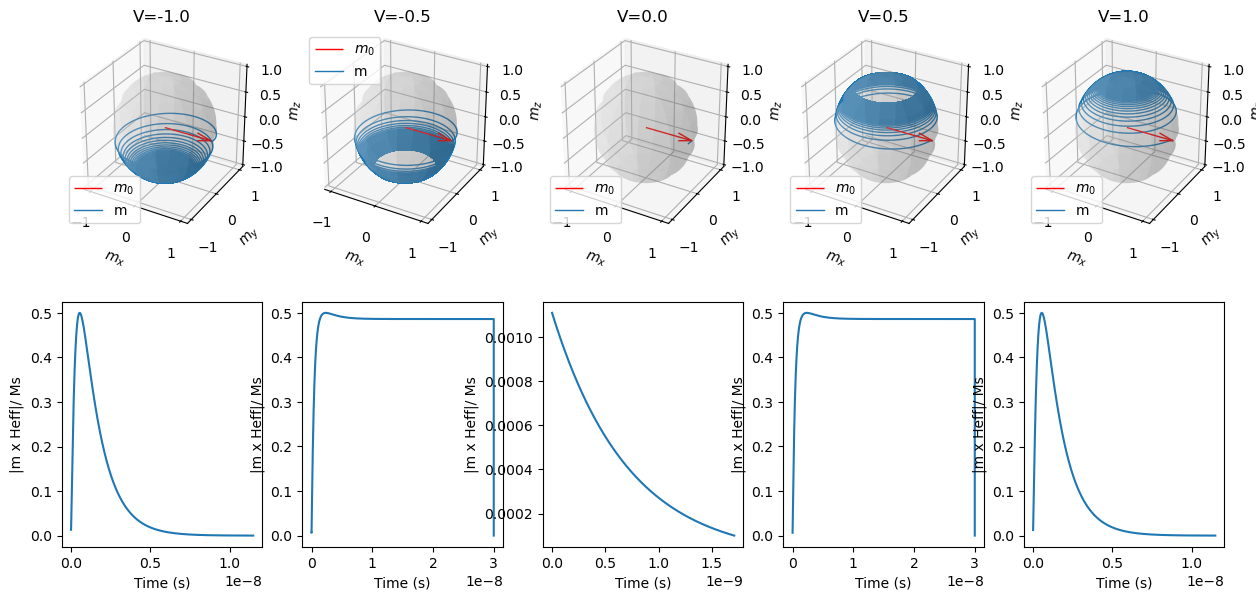

In [13]:
fig = plt.figure(figsize=(15, 7))
V = np.arange(-1, 1.1, 0.5)
for i, V_i in enumerate(V):
    m, energy, time_series = calculate_magnetization(
        Tn=3e-8 ,H_app=np.array([0, 0, 0]), voltage=V_i
    )

    sphere_ax = fig.add_subplot(2, len(V), i + 1, projection="3d")
    plot_unit_sphere(sphere_ax, m, "m", f"V={V_i}")
    
    ax = fig.add_subplot(2, len(V), len(V) + 1 + i)
    ax.plot(time_series, energy)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("|m x Heff|/ Ms")